In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from src.utils import *

import pandas as pd
import numpy as py

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from matplotlib import pyplot as plt

import seaborn as sea

In [3]:
# Loading dataset
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

In [10]:
# Cardinality analysis (again lol)
columns = train.select_dtypes(
    include=["object", "category"]
).columns

for col in columns:
    print(f"{col}: {train[col].nunique()}")

Driver: 887
Compound: 5
Race: 26


C:\Users\tyler\AppData\Local\Temp\ipykernel_42172\3706961944.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns = train.select_dtypes(


In [ ]:
# Checking the target distribution
train["PitNextLap"].value_counts()
train["PitNextLap"].value_counts(normalize=True)

PitNextLap
0.0    0.801018
1.0    0.198982
Name: proportion, dtype: float64

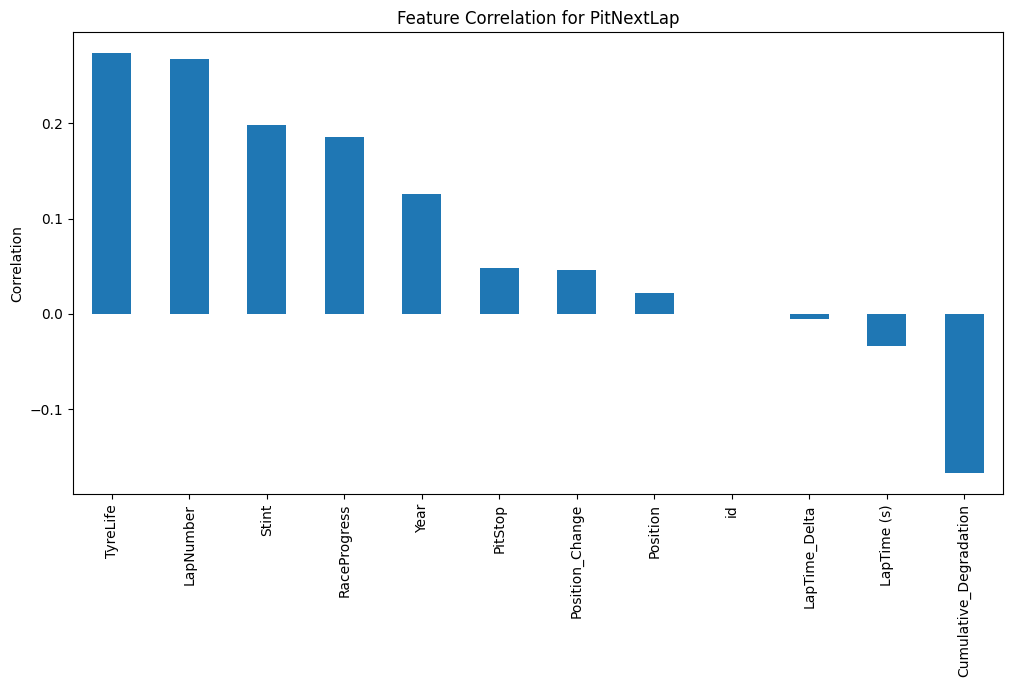

In [8]:
numerical_cols = train.select_dtypes(
    include=["int64", "float64"]
).columns

# Correlation matrix
correlation_matrix = train[numerical_cols].corr()

# Correlation with the target variable
target_correlations = correlation_matrix["PitNextLap"].sort_values(
    ascending=False
)

# Plotting on graph
target_correlations.drop("PitNextLap").plot(kind="bar", figsize=(12,6))

plt.title("Feature Correlation for PitNextLap")
plt.ylabel("Correlation")
plt.show()

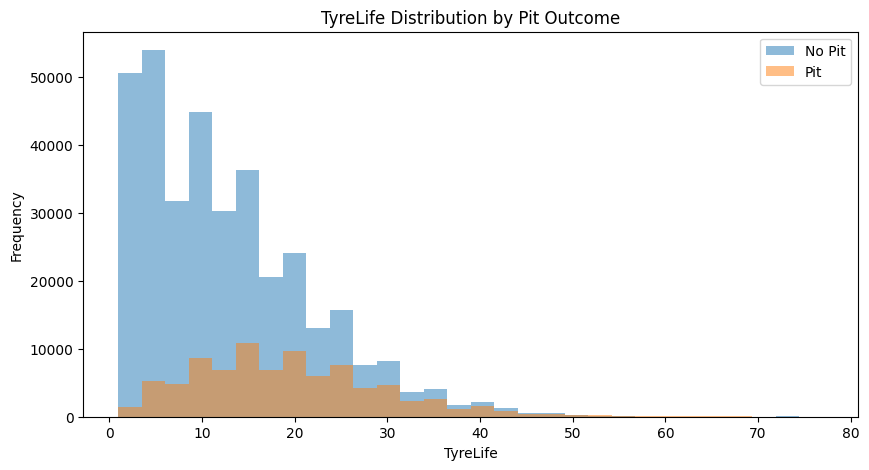

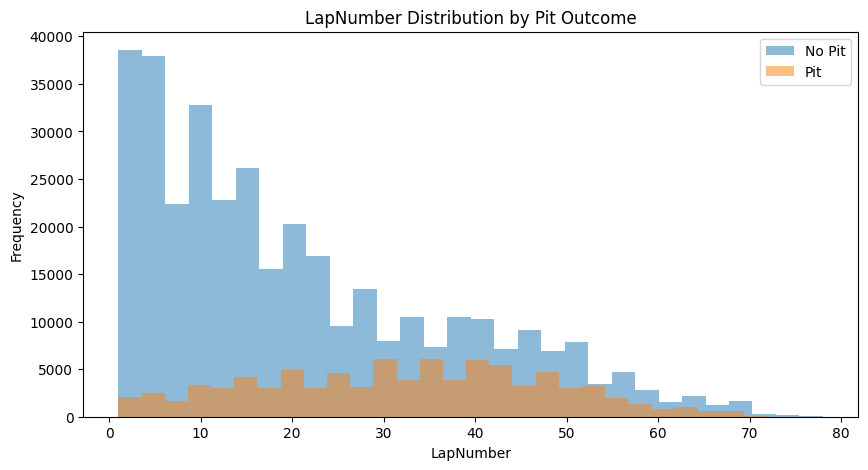

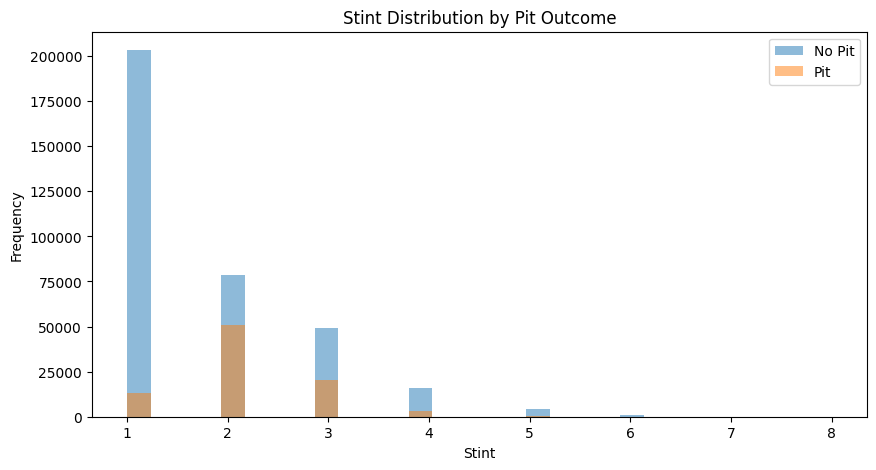

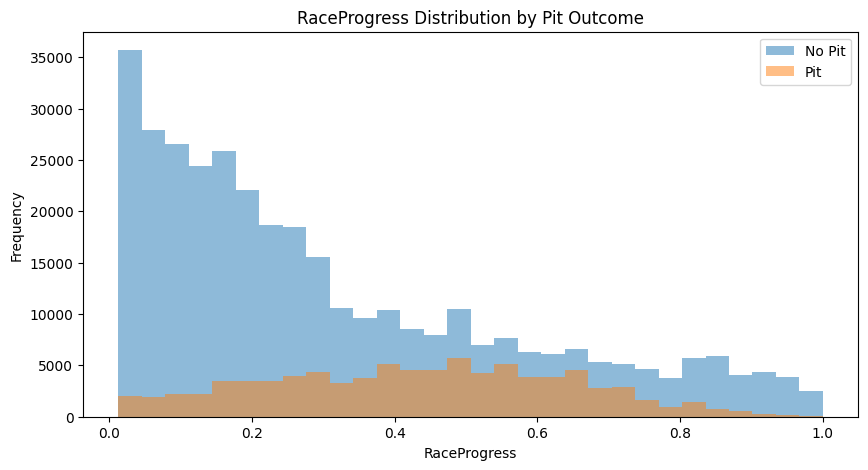

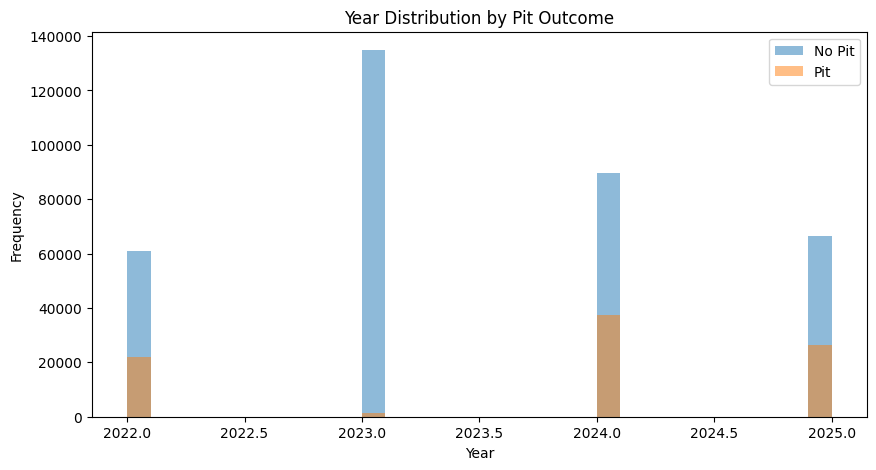

In [ ]:
# Comparative histogram for all +ve correlation features found that i found relevant
main_features = [
    "TyreLife",
    "LapNumber",
    "Stint",
    "RaceProgress",
    "Year"
]

for feature in main_features:

    plt.figure(figsize=(10,5))

    # Plots a comparative histogram for pitting vs not 
    plt.hist(
        train[train["PitNextLap"] == 0][feature],
        bins=30,
        alpha=0.5,
        label="No Pit"
    )

    plt.hist(
        train[train["PitNextLap"] == 1][feature],
        bins=30,
        alpha=0.5,
        label="Pit"
    )

    plt.title(f"{feature} Distribution by Pit Outcome")

    plt.xlabel(feature)

    plt.ylabel("Frequency")

    plt.legend()

    plt.show()

C:\Users\tyler\AppData\Local\Temp\ipykernel_39536\3541550576.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\tyler\AppData\Local\Temp\ipykernel_39536\3541550576.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\tyler\AppData\Local\Temp\ipykernel_39536\3541550576.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\tyler\AppData\Local\Temp\ipykernel_39536\3541550576.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3

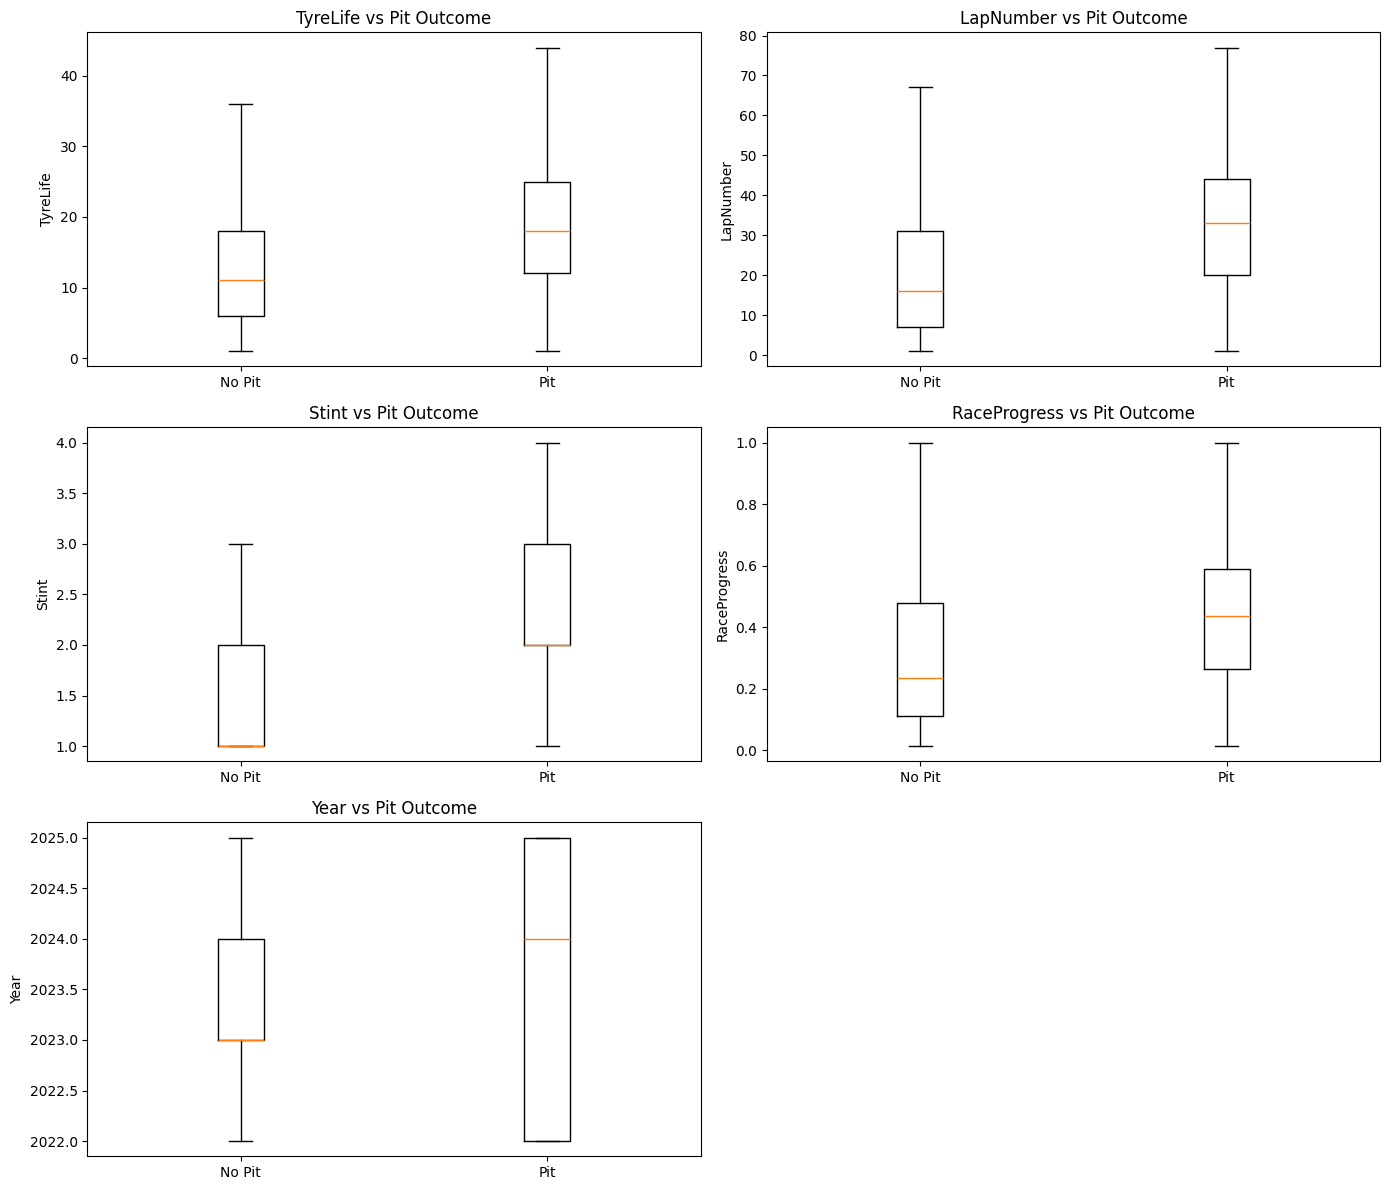

In [15]:
# Comparative box plot graph for the same correlation features
main_features = [
    "TyreLife",
    "LapNumber",
    "Stint",
    "RaceProgress",
    "Year"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes = axes.flatten()

for i, feature in enumerate(main_features):

    axes[i].boxplot(
        [
            train[train["PitNextLap"] == 0][feature],
            train[train["PitNextLap"] == 1][feature]
        ],
        labels=["No Pit", "Pit"],
        showfliers=False
    )

    axes[i].set_title(f"{feature} vs Pit Outcome")

    axes[i].set_ylabel(feature)

fig.delaxes(axes[5])

plt.tight_layout()

plt.show()

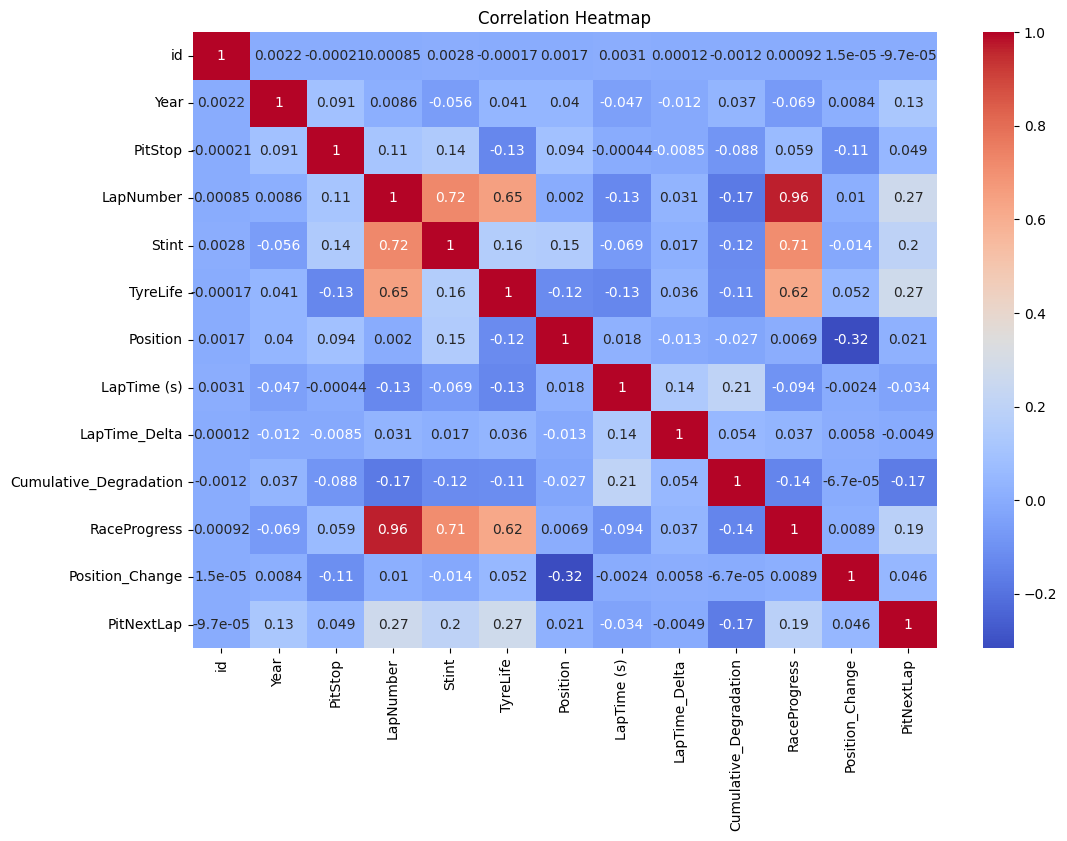

In [5]:
# Correlation heatmap
correlation_matrix = train.corr(numeric_only=True)
plt.figure(figsize=(12,8))

sea.heatmap(correlation_matrix, cmap="coolwarm", annot=True)

plt.title("Correlation Heatmap")
plt.show()
